# 3. Representation Learning

## Q3.1 Pretraining and Linear Probes

In [2]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import torch

In [3]:
# 1. Load data          
df_train = pd.read_parquet("processed/set_a_processed.parquet")
df_val   = pd.read_parquet("processed/set_b_processed.parquet")
df_test  = pd.read_parquet("processed/set_c_processed.parquet")

#2. Prepare data for modeling
feature_cols = [c for c in df_train.columns 
                if c not in ["In-hospital_death", "RecordID", "ICUType", "hour"]]


def get_labels_and_features(df):
    # get labels — one per patient
    y = df.groupby("RecordID")["In-hospital_death"].first().values

    # get features — group by patient, sort by hour, then reshape
    X = (df.sort_values(["RecordID", "hour"])
             .groupby("RecordID")[feature_cols]
             .apply(lambda x: x.values)  # each patient becomes (49, 41)
             .values)

    X = np.stack(X)  # shape: (N_patients, 49, 41)
    X = torch.tensor(X, dtype=torch.float32)
    
    return X, y

X_train, y_train = get_labels_and_features(df_train)    
X_val, y_val = get_labels_and_features(df_val)
X_test, y_test = get_labels_and_features(df_test)
              


## Build the LSTM encoder

In [4]:
#build the LSTM autoencoder
import torch.nn as nn       

class LSTMAutoencoder(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(LSTMAutoencoder, self).__init__()
        self.encoder = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.decoder = nn.LSTM(hidden_size, input_size, batch_first=True)

    def forward(self, x):
        _, (h_n, _) = self.encoder(x)  # h_n shape: (1, batch_size, hidden_size)
        h_n = h_n.squeeze(0)  # shape: (batch_size, hidden_size)
        h_n = h_n.unsqueeze(0)  # shape: (1, batch_size, hidden_size)
        decoded, _ = self.decoder(h_n.repeat(x.size(1), 1, 1).permute(1, 0, 2))
        return decoded                                                          


## Train with MSE loss between input and reconstruction

In [5]:
from torch.utils.data import DataLoader, TensorDataset

input_size = X_train.shape[2]  # number of features (41)
hidden_size = 64                # latent representation size
batch_size = 64

model = LSTMAutoencoder(input_size, hidden_size)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# DataLoaders for mini-batch training
train_loader = DataLoader(TensorDataset(X_train), batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val),   batch_size=batch_size, shuffle=False)

## Monitor Pretraining

In [6]:
import matplotlib.pyplot as plt

num_epochs = 20
train_losses, val_losses = [], []

for epoch in range(num_epochs):
    # --- Training ---
    model.train()
    epoch_train_loss = 0.0
    for (batch,) in train_loader:
        optimizer.zero_grad()
        outputs = model(batch)
        loss = criterion(outputs, batch)
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item() * batch.size(0)
    epoch_train_loss /= len(train_loader.dataset)

    # --- Validation ---
    model.eval()
    epoch_val_loss = 0.0
    with torch.no_grad():
        for (batch,) in val_loader:
            outputs = model(batch)
            loss = criterion(outputs, batch)
            epoch_val_loss += loss.item() * batch.size(0)
    epoch_val_loss /= len(val_loader.dataset)

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    print(f"Epoch {epoch+1:>2}/{num_epochs} — train: {epoch_train_loss:.4f}, val: {epoch_val_loss:.4f}")

# Save model weights for downstream use
torch.save(model.state_dict(), "lstm_autoencoder.pt")
print("Model saved to lstm_autoencoder.pt")

Epoch  1/20 — train: 35.5530, val: 25.5096
Epoch  2/20 — train: 35.1605, val: 25.3592
Epoch  3/20 — train: 35.0660, val: 25.2996
Epoch  4/20 — train: 35.0166, val: 25.2636
Epoch  5/20 — train: 34.9826, val: 25.2364
Epoch  6/20 — train: 34.9554, val: 25.2126
Epoch  7/20 — train: 34.9324, val: 25.1910
Epoch  8/20 — train: 34.9118, val: 25.1703
Epoch  9/20 — train: 34.8930, val: 25.1518
Epoch 10/20 — train: 34.8779, val: 25.1379
Epoch 11/20 — train: 34.8657, val: 25.1263
Epoch 12/20 — train: 34.8561, val: 25.1174
Epoch 13/20 — train: 34.8485, val: 25.1106
Epoch 14/20 — train: 34.8423, val: 25.1045
Epoch 15/20 — train: 34.8370, val: 25.1000
Epoch 16/20 — train: 34.8329, val: 25.0963
Epoch 17/20 — train: 34.8291, val: 25.0924
Epoch 18/20 — train: 34.8259, val: 25.0888
Epoch 19/20 — train: 34.8237, val: 25.0881
Epoch 20/20 — train: 34.8211, val: 25.0848
Model saved to lstm_autoencoder.pt


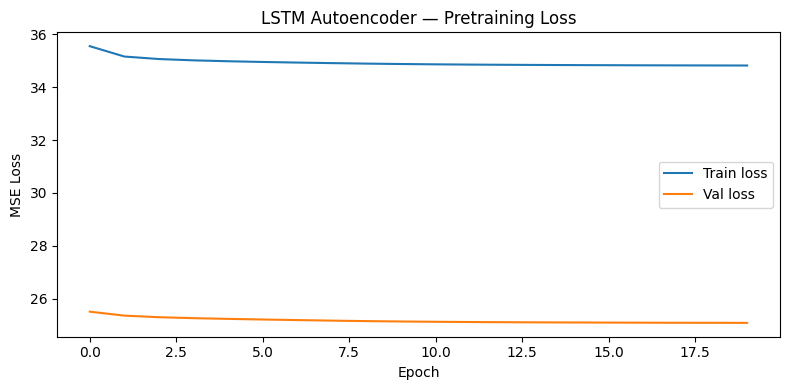

In [7]:
# Plot loss curves
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="Train loss")
plt.plot(val_losses,   label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("LSTM Autoencoder — Pretraining Loss")
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
def encode(X, model, batch_size=64):
    loader = DataLoader(TensorDataset(X), batch_size=batch_size, shuffle=False)
    zs = []
    model.eval()
    with torch.no_grad():
        for (batch,) in loader:
            _, (h_n, _) = model.encoder(batch)
            zs.append(h_n.squeeze(0))
    return torch.cat(zs, dim=0)

In [9]:
# Load pretrained weights
model.load_state_dict(torch.load("lstm_autoencoder.pt"))

# Freeze encoder
for param in model.encoder.parameters():
    param.requires_grad = False

# Pass every patient through frozen encoder: 64-dim vector per patient
z_train = encode(X_train, model)
z_val   = encode(X_val,   model)
z_test  = encode(X_test,  model)

lr = LogisticRegression(max_iter=1000)
lr.fit(z_train.numpy(), y_train)
y_val_pred = lr.predict_proba(z_val.numpy())[:, 1]
auc = roc_auc_score(y_val, y_val_pred)
print(f"Logistic Regression AUC on validation set: {auc:.4f}")

Logistic Regression AUC on validation set: 0.8483


## Q3.2 Simulate label scarcity (4 pts)